# Кластеризация сигналов сцинтилляционного детектора

В работе исходные временные ряды преобразуются в физически интерпретируемые признаки, затем сравниваются несколько алгоритмов кластеризации и выбирается финальная модель для разбиения сигналов на три кластера.

## 1. Импорты

В первой ячейке собраны только библиотеки

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler, StandardScaler

Фиксируем случайное зерно. Это нужно для воспроизводимости PCA, моделей с вероятностной инициализацией и выбора подвыборки для расчёта метрик

In [2]:
RANDOM_STATE = 42
N_CLUSTERS = 3
rng = np.random.default_rng(RANDOM_STATE)

## 2. Загрузка данных


In [3]:
data_path = next(Path('/kaggle/input').rglob('Run200_Wave_0_1.txt'))
raw_data = pd.read_csv(data_path, sep=' ', header=None, skipinitialspace=True)
raw_data = raw_data.dropna(axis=1, how='all')

raw_data.shape

(23479, 504)

In [4]:
raw_data.head()

,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


**Вывод по этапу загрузки данных.**  
Данные представлены одной таблицей: одна строка соответствует одному зарегистрированному импульсу. После удаления пустого технического столбца остаются 4 служебных поля и 500 отсчётов сигнала.

## 3. Исследование и анализ датасета

Разделим таблицу на служебные параметры и временные ряды.

In [5]:
metadata = raw_data.iloc[:, :4].copy()
waveforms = raw_data.iloc[:, 4:504].copy()

metadata.columns = ['meta_0', 'meta_1', 'meta_2', 'signal_length']
waveforms.columns = [f't_{i}' for i in range(waveforms.shape[1])]

print('metadata:', metadata.shape)
print('waveforms:', waveforms.shape)

metadata: (23479, 4)
waveforms: (23479, 500)


In [6]:
metadata.describe().T

,count,mean,std,min,25%,50%,75%,max
meta_0,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
meta_1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
meta_2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
signal_length,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02


In [7]:
pd.DataFrame({
    'missing_count': raw_data.isna().sum(),
    'missing_share': raw_data.isna().mean(),
}).query('missing_count > 0')

,missing_count,missing_share


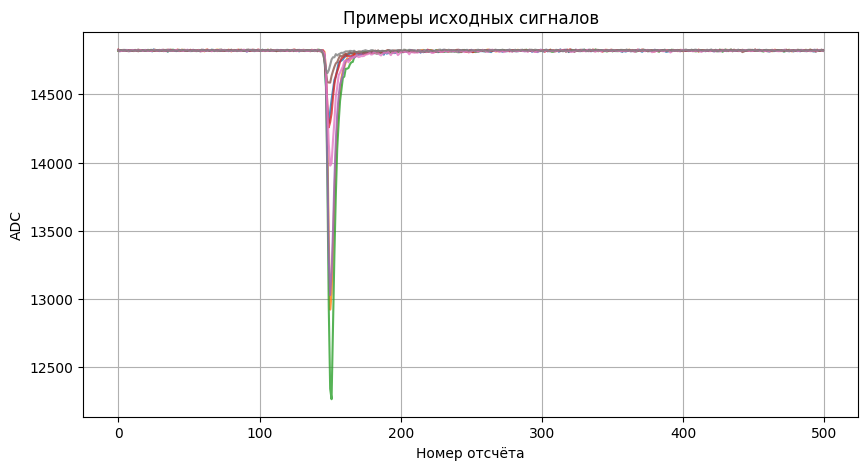

In [8]:
plt.figure(figsize=(10, 5))
for idx in range(8):
    plt.plot(waveforms.iloc[idx].values, alpha=0.8)

plt.title('Примеры исходных сигналов')
plt.xlabel('Номер отсчёта')
plt.ylabel('ADC')
plt.grid(True)
plt.show()

Исходные сигналы направлены вниз относительно базовой линии. Для анализа удобнее перейти к положительному импульсу: инвертировать шкалу АЦП и вычесть базовую линию, рассчитанную по начальным отсчётам до появления импульса.

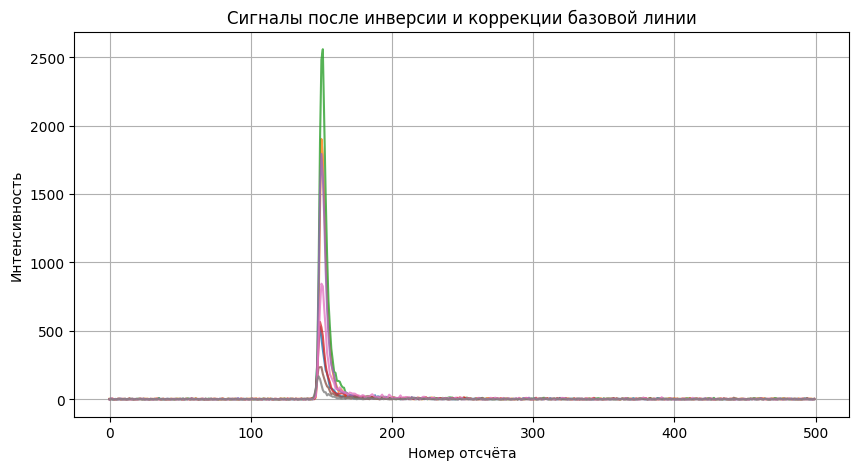

In [9]:
raw_signal = 2 ** 14 - waveforms.to_numpy(dtype=np.float32) - 1560
baseline = np.median(raw_signal[:, :120], axis=1, keepdims=True)
corrected_signal = raw_signal - baseline
positive_signal = np.clip(corrected_signal, 0, None)

plt.figure(figsize=(10, 5))
for idx in range(8):
    plt.plot(positive_signal[idx], alpha=0.8)

plt.title('Сигналы после инверсии и коррекции базовой линии')
plt.xlabel('Номер отсчёта')
plt.ylabel('Интенсивность')
plt.grid(True)
plt.show()

In [10]:
peak_index = positive_signal.argmax(axis=1)
amplitude = positive_signal.max(axis=1)
area_total = positive_signal.sum(axis=1)
area_to_amplitude = area_total / (amplitude + 1e-9)
noise_std = corrected_signal[:, :120].std(axis=1)

eda_features = pd.DataFrame({
    'peak_index': peak_index,
    'amplitude': amplitude,
    'area_total': area_total,
    'area_to_amplitude': area_to_amplitude,
    'noise_std': noise_std,
})

eda_features.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.round(3)

,count,mean,std,min,1%,5%,50%,95%,99%,max
peak_index,23479.0,149.629,2.490,145.000,146.000,147.000,150.000,151.000,152.000,472.000
amplitude,23479.0,1835.174,2389.307,104.000,121.500,142.000,813.000,7187.100,11066.880,14824.000
area_total,23479.0,13534.925,16030.431,948.000,1321.340,1606.000,6641.000,49107.700,73317.600,113304.000
area_to_amplitude,23479.0,8.709,1.999,5.434,6.166,6.323,8.450,12.553,14.353,19.296
noise_std,23479.0,2.701,0.177,2.014,2.314,2.425,2.698,2.986,3.111,10.094


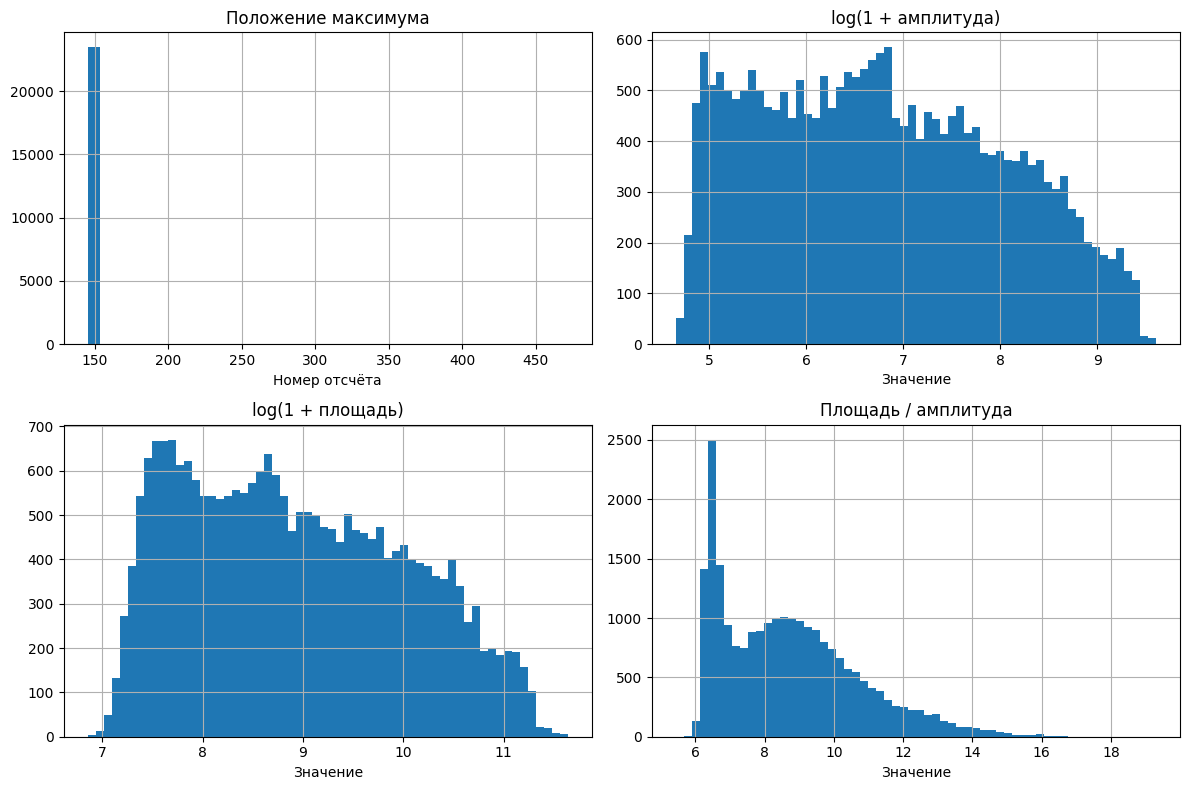

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(eda_features['peak_index'], bins=40)
axes[0, 0].set_title('Положение максимума')
axes[0, 0].set_xlabel('Номер отсчёта')

axes[0, 1].hist(np.log1p(eda_features['amplitude']), bins=60)
axes[0, 1].set_title('log(1 + амплитуда)')
axes[0, 1].set_xlabel('Значение')

axes[1, 0].hist(np.log1p(eda_features['area_total']), bins=60)
axes[1, 0].set_title('log(1 + площадь)')
axes[1, 0].set_xlabel('Значение')

axes[1, 1].hist(eda_features['area_to_amplitude'], bins=60)
axes[1, 1].set_title('Площадь / амплитуда')
axes[1, 1].set_xlabel('Значение')

for ax in axes.ravel():
    ax.grid(True)

plt.tight_layout()
plt.show()

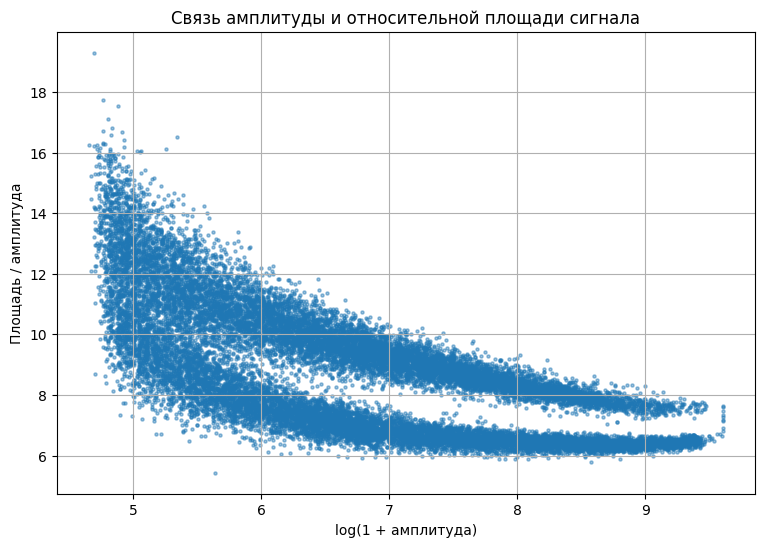

In [12]:
plt.figure(figsize=(9, 6))
plt.scatter(
    np.log1p(eda_features['amplitude']),
    eda_features['area_to_amplitude'],
    s=5,
    alpha=0.45,
)
plt.title('Связь амплитуды и относительной площади сигнала')
plt.xlabel('log(1 + амплитуда)')
plt.ylabel('Площадь / амплитуда')
plt.grid(True)
plt.show()

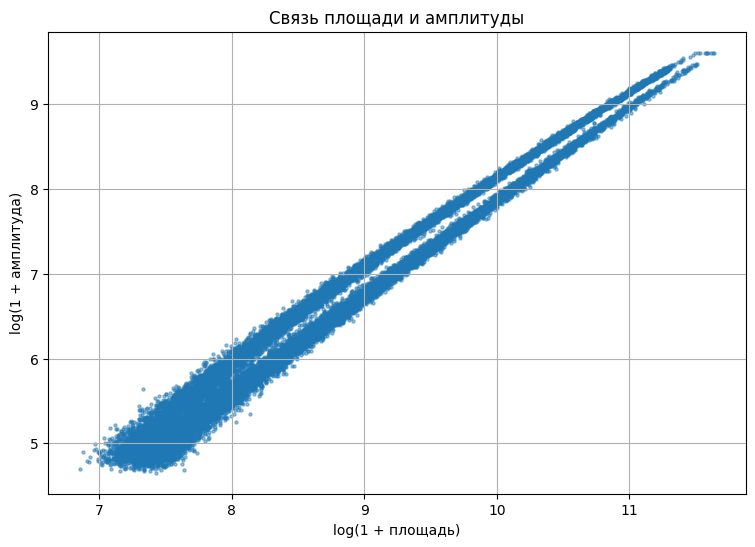

In [13]:
plt.figure(figsize=(9, 6))
plt.scatter(
    np.log1p(eda_features['area_total']),
    np.log1p(eda_features['amplitude']),
    s=5,
    alpha=0.45,
)
plt.title('Связь площади и амплитуды')
plt.xlabel('log(1 + площадь)')
plt.ylabel('log(1 + амплитуда)')
plt.grid(True)
plt.show()

**Вывод по этапу анализа данных.**  
Пик сигнала в большинстве наблюдений расположен в близкой временной области, поэтому можно использовать окна интегрирования относительно максимума. На диаграммах видны различия не только по амплитуде, но и по форме импульса: отношение площади к амплитуде и доля хвоста формируют области с разным поведением. Это соответствует физической идее PSD-разделения, где частицы различаются вкладом медленной компоненты сигнала.

## 4. Предобработка и Feature Engineering

Вместо 500 исходных отсчётов для каждого сигнала рассчитаем компактные признаки: амплитуду, площадь, PSD-параметры, долю хвоста и временные характеристики спада. Аномальные сигналы не удаляются, потому что отдельный кластер 2 как раз должен их выделять.

In [14]:
def build_signal_features(signal_values):
    n_objects, n_points = signal_values.shape
    rows = np.arange(n_objects)
    time_axis = np.arange(n_points, dtype=np.float32)

    raw_positive = np.clip(signal_values, 0, None)
    peak_idx = raw_positive.argmax(axis=1)
    amplitude = raw_positive.max(axis=1)
    area = raw_positive.sum(axis=1)

    cumsum = np.concatenate([
        np.zeros((n_objects, 1), dtype=np.float32),
        np.cumsum(raw_positive, axis=1),
    ], axis=1)

    def interval_sum(start, end):
        start = np.clip(np.asarray(start), 0, n_points).astype(int)
        end = np.clip(np.asarray(end), 0, n_points).astype(int)
        return cumsum[rows, end] - cumsum[rows, start]

    gate_30 = interval_sum(peak_idx, peak_idx + 30)
    gate_60 = interval_sum(peak_idx, peak_idx + 60)
    tail_after_20 = interval_sum(peak_idx + 20, np.full(n_objects, n_points))
    tail_after_40 = interval_sum(peak_idx + 40, np.full(n_objects, n_points))
    tail_20_120 = interval_sum(peak_idx + 20, peak_idx + 120)
    tail_30_160 = interval_sum(peak_idx + 30, peak_idx + 160)
    long_160 = interval_sum(peak_idx, peak_idx + 160)

    eps = 1e-9
    relative_time = np.clip(time_axis[None, :] - peak_idx[:, None], 0, None)
    weights = raw_positive / (area[:, None] + eps)
    mean_time = (weights * relative_time).sum(axis=1)
    std_time = np.sqrt((weights * (relative_time - mean_time[:, None]) ** 2).sum(axis=1))

    cumulative = np.cumsum(raw_positive, axis=1)

    def time_quantile(q):
        threshold = (area * q)[:, None]
        return np.argmax(cumulative >= threshold, axis=1).astype(np.float32) - peak_idx

    def time_above_fraction(frac):
        mask = raw_positive >= (amplitude[:, None] * frac)
        mask &= time_axis[None, :] >= peak_idx[:, None]
        return mask.sum(axis=1)

    features = pd.DataFrame({
        'amplitude': amplitude,
        'log_amplitude': np.log1p(amplitude),
        'area_total': area,
        'log_area': np.log1p(area),
        'peak_index': peak_idx,
        'noise_std': corrected_signal[:, :120].std(axis=1),
        'area_to_amplitude': area / (amplitude + eps),
        'psd_30': (area - gate_30) / (area + eps),
        'psd_60': (area - gate_60) / (area + eps),
        'tail_after_20_ratio': tail_after_20 / (area + eps),
        'tail_after_40_ratio': tail_after_40 / (area + eps),
        'tail_20_120_ratio': tail_20_120 / (long_160 + eps),
        'tail_30_160_ratio': tail_30_160 / (long_160 + eps),
        'tail_peak_ratio': tail_after_20 / (gate_30 + eps),
        'mean_time': mean_time,
        'std_time': std_time,
        'decay_q90_q50': time_quantile(0.90) - time_quantile(0.50),
        'decay_q75_q25': time_quantile(0.75) - time_quantile(0.25),
        'width_50': time_above_fraction(0.50),
        'width_25': time_above_fraction(0.25),
    })

    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(features.median(numeric_only=True))
    return features

features = build_signal_features(corrected_signal)
features.head()

,amplitude,log_amplitude,area_total,log_area,peak_index,noise_std,area_to_amplitude,psd_30,psd_60,tail_after_20_ratio,tail_after_40_ratio,tail_20_120_ratio,tail_30_160_ratio,tail_peak_ratio,mean_time,std_time,decay_q90_q50,decay_q75_q25,width_50,width_25
0,529.0,6.272877,4597.0,8.433376,149,2.760724,8.689981,0.375897,0.303024,0.223189,0.155536,0.201994,0.182621,0.357616,25.635414,60.160041,71.0,14.0,4,7
1,1902.0,7.551187,12836.0,9.460087,150,2.674520,6.748685,0.272359,0.250312,0.099408,0.074322,0.075629,0.064409,0.136617,15.032876,49.516736,17.0,5.0,4,6
2,2558.0,7.847372,17290.0,9.757941,151,2.455592,6.759187,0.396992,0.379410,0.070677,0.054135,0.066619,0.062663,0.117207,10.690862,40.618545,11.0,5.0,3,5
3,565.0,6.338594,5090.0,8.535230,149,2.745906,9.008849,0.344990,0.297642,0.221611,0.155599,0.180851,0.155522,0.338332,27.717093,63.453037,90.0,15.0,4,7
4,1793.0,7.492203,11875.0,9.382275,150,2.695044,6.622978,0.278316,0.262484,0.068126,0.045895,0.058594,0.045338,0.094399,9.627453,36.430780,11.0,4.0,4,6


In [15]:
features.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(3)

,mean,std,min,25%,50%,75%,max
amplitude,1835.174,2389.307,104.000,308.000,813.000,2315.000,14824.000
log_amplitude,6.782,1.232,4.654,5.733,6.702,7.748,9.604
area_total,13534.925,16030.431,948.000,2905.000,6641.000,17625.000,113304.000
log_area,8.920,1.090,6.855,7.975,8.801,9.777,11.638
peak_index,149.629,2.490,145.000,149.000,150.000,151.000,472.000
noise_std,2.701,0.177,2.014,2.585,2.698,2.815,10.094
area_to_amplitude,8.709,1.999,5.434,6.907,8.450,9.920,19.296
psd_30,0.386,0.087,0.189,0.324,0.373,0.439,0.717
psd_60,0.347,0.083,0.170,0.286,0.332,0.394,0.691
tail_after_20_ratio,0.183,0.085,0.010,0.107,0.186,0.243,0.465


**Вывод по этапу предобработки и Feature Engineering.**  
Исходные временные ряды преобразованы в признаки, связанные с физикой сигнала. Амплитуда и площадь отражают энергию импульса, PSD-признаки и отношение площади к амплитуде описывают вклад медленной компоненты, а временные признаки характеризуют ширину и спад сигнала. Такой набор удобнее для кластеризации и интерпретации, чем 500 отсчётов.

## 5. Подбор признаков, анализ зависимостей и важности

Перед обучением моделей проверим корреляции и выберем признаки, которые описывают форму сигнала. Для финального разделения особенно важны PSD-признаки и временные характеристики хвоста.

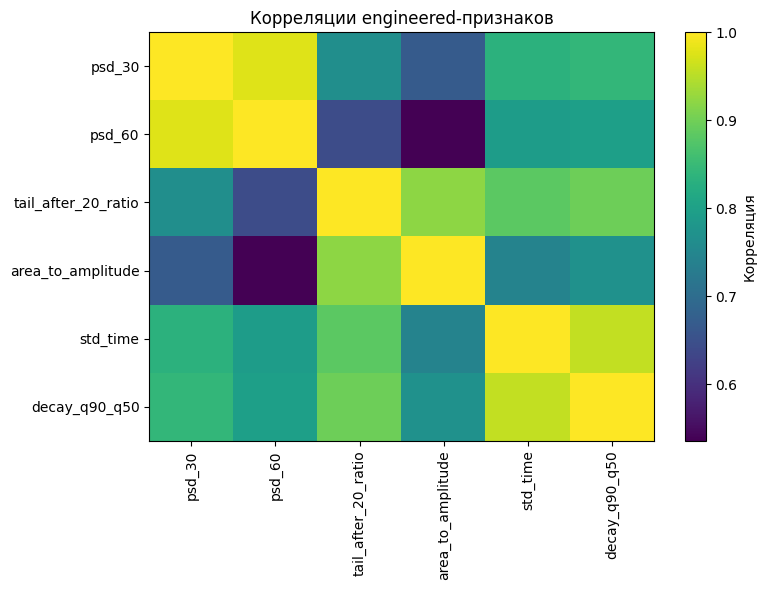

In [16]:
model_features = [
    'psd_30',
    'psd_60',
    'tail_after_20_ratio',
    'area_to_amplitude',
    'std_time',
    'decay_q90_q50',
]

model_data = features[model_features].copy()

corr = model_data.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Корреляция')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Корреляции engineered-признаков')
plt.tight_layout()
plt.show()

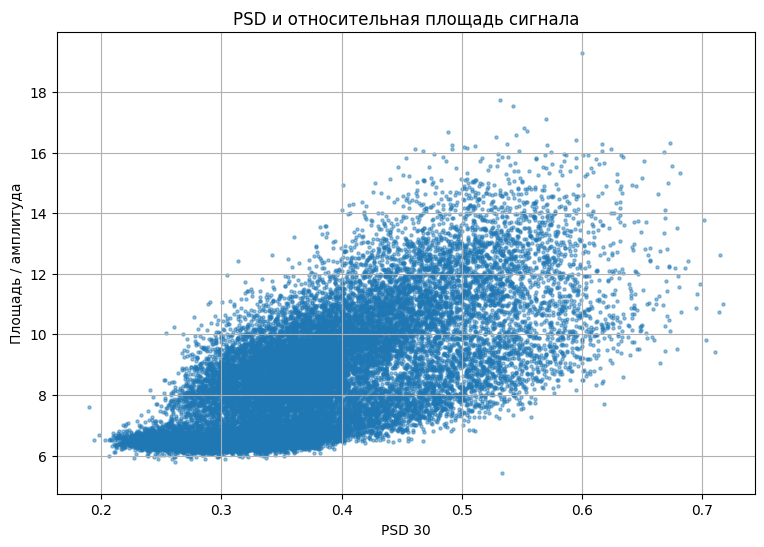

In [17]:
plt.figure(figsize=(9, 6))
plt.scatter(
    features['psd_30'],
    features['area_to_amplitude'],
    s=5,
    alpha=0.45,
)
plt.title('PSD и относительная площадь сигнала')
plt.xlabel('PSD 30')
plt.ylabel('Площадь / амплитуда')
plt.grid(True)
plt.show()

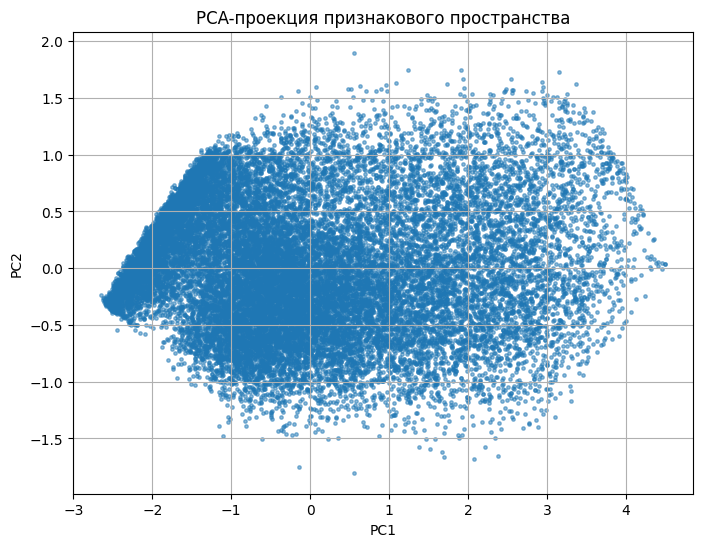

PC1    0.834546
PC2    0.116841
Name: explained_variance_ratio, dtype: float64

In [18]:
def clip_by_quantiles(frame, columns, lower=0.005, upper=0.995):
    result = frame[columns].copy()
    for column in columns:
        q_low, q_high = result[column].quantile([lower, upper])
        result[column] = result[column].clip(q_low, q_high)
    return result

clipped_model_data = clip_by_quantiles(features, model_features)
scaler = RobustScaler()
X = scaler.fit_transform(clipped_model_data)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=6, alpha=0.5)
plt.title('PCA-проекция признакового пространства')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

pd.Series(pca.explained_variance_ratio_, index=['PC1', 'PC2']).rename('explained_variance_ratio')

**Вывод по этапу подбора и анализа признаков.**  
Многие признаки коррелируют, так как описывают одну и ту же физическую форму импульса разными способами. Для обучения оставлены признаки хвоста, PSD, отношения площади к амплитуде и временной ширины. Масштабирование выполняется через `RobustScaler`, потому что в данных есть редкие сильные импульсы, которые не нужно удалять, но нужно снизить их влияние на масштаб.

## 6. Обучение нескольких моделей и подбор гиперпараметров

Сравниваем несколько подходов: `KMeans`, `GaussianMixture` и `AgglomerativeClustering` на подвыборке. Отдельно проверяются две финальные схемы: вероятностная GMM с кластером низкой уверенности и PCA-разделение на плоскости `log(area)` / `log(amplitude)`. Вторая схема важна, потому что на EDA сигналы образуют две вытянутые ветви, которые хорошо разделяются по отклонению от главной компоненты.

In [19]:
model_sample_size = min(1000, X.shape[0])
model_indices = rng.choice(X.shape[0], size=model_sample_size, replace=False)
X_model_sample = X[model_indices]


def calculate_metrics(X_values, labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return np.nan, np.nan, np.nan

    return (
        silhouette_score(X_values, labels),
        calinski_harabasz_score(X_values, labels),
        davies_bouldin_score(X_values, labels),
    )

In [20]:
results = []

for n_clusters in [2, 3, 4]:
    model = KMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=100,
    )
    labels = model.fit_predict(X_model_sample)
    sil, ch, db = calculate_metrics(X_model_sample, labels)
    results.append({
        'model': 'KMeans',
        'params': f'n_clusters={n_clusters}',
        'clusters': len(np.unique(labels)),
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
    })

for covariance_type in ['diag', 'full']:
    for n_components in [2, 3]:
        model = GaussianMixture(
            n_components=n_components,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE,
            n_init=1,
            max_iter=100,
            reg_covar=1e-6,
        )
        labels = model.fit_predict(X_model_sample)
        sil, ch, db = calculate_metrics(X_model_sample, labels)
        results.append({
            'model': 'GaussianMixture',
            'params': f'n_components={n_components}, covariance={covariance_type}',
            'clusters': len(np.unique(labels)),
            'silhouette': sil,
            'calinski_harabasz': ch,
            'davies_bouldin': db,
        })

agg_sample_size = min(700, X.shape[0])
agg_indices = rng.choice(X.shape[0], size=agg_sample_size, replace=False)
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X[agg_indices])
sil, ch, db = calculate_metrics(X[agg_indices], labels)
results.append({
    'model': 'AgglomerativeClustering',
    'params': f'n_clusters=3, linkage=ward, sample={agg_sample_size}',
    'clusters': len(np.unique(labels)),
    'silhouette': sil,
    'calinski_harabasz': ch,
    'davies_bouldin': db,
})

results_df = pd.DataFrame(results)
results_df.sort_values('silhouette', ascending=False)

,model,params,clusters,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,n_clusters=2,2,0.507033,1590.054308,0.738298
3,GaussianMixture,"n_components=2, covariance=diag",2,0.491271,1523.390602,0.760385
5,GaussianMixture,"n_components=2, covariance=full",2,0.399300,1054.244158,0.863991
7,AgglomerativeClustering,"n_clusters=3, linkage=ward, sample=700",3,0.387899,762.329751,1.010261
1,KMeans,n_clusters=3,3,0.384145,1402.825576,0.908243
4,GaussianMixture,"n_components=3, covariance=diag",3,0.356543,1195.468229,0.906551
2,KMeans,n_clusters=4,4,0.335351,1247.920853,1.012720
6,GaussianMixture,"n_components=3, covariance=full",3,0.288500,835.077750,0.998989


In [21]:
ranked_results = results_df.copy()
ranked_results['silhouette_rank'] = ranked_results['silhouette'].rank(ascending=False)
ranked_results['calinski_rank'] = ranked_results['calinski_harabasz'].rank(ascending=False)
ranked_results['davies_rank'] = ranked_results['davies_bouldin'].rank(ascending=True)
ranked_results['total_rank'] = (
    ranked_results['silhouette_rank']
    + ranked_results['calinski_rank']
    + ranked_results['davies_rank']
)

ranked_results.sort_values('total_rank').head(15)

,model,params,clusters,silhouette,calinski_harabasz,davies_bouldin,silhouette_rank,calinski_rank,davies_rank,total_rank
0,KMeans,n_clusters=2,2,0.507033,1590.054308,0.738298,1.0,1.0,1.0,3.0
3,GaussianMixture,"n_components=2, covariance=diag",2,0.491271,1523.390602,0.760385,2.0,2.0,2.0,6.0
5,GaussianMixture,"n_components=2, covariance=full",2,0.399300,1054.244158,0.863991,3.0,6.0,3.0,12.0
1,KMeans,n_clusters=3,3,0.384145,1402.825576,0.908243,5.0,3.0,5.0,13.0
4,GaussianMixture,"n_components=3, covariance=diag",3,0.356543,1195.468229,0.906551,6.0,5.0,4.0,15.0
2,KMeans,n_clusters=4,4,0.335351,1247.920853,1.012720,7.0,4.0,8.0,19.0
7,AgglomerativeClustering,"n_clusters=3, linkage=ward, sample=700",3,0.387899,762.329751,1.010261,4.0,8.0,7.0,19.0
6,GaussianMixture,"n_components=3, covariance=full",3,0.288500,835.077750,0.998989,8.0,7.0,6.0,21.0


Для финальной постановки отдельно проверяется GMM с двумя основными компонентами и порогом уверенности. Если модель не уверена, к какому из двух основных типов относится сигнал, этот объект переносится в кластер 2.

In [22]:
final_fit_sample_size = min(3000, X.shape[0])
final_fit_indices = rng.choice(X.shape[0], size=final_fit_sample_size, replace=False)

gmm_base = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=1,
    max_iter=120,
    reg_covar=1e-6,
)

gmm_base.fit(X[final_fit_indices])
base_labels = gmm_base.predict(X)
base_confidence = gmm_base.predict_proba(X).max(axis=1)

threshold_results = []

for threshold in [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    labels = base_labels.copy()
    labels[base_confidence < threshold] = 2
    sil, ch, db = calculate_metrics(X_model_sample, labels[model_indices])
    counts = pd.Series(labels).value_counts().sort_index().to_dict()
    threshold_results.append({
        'model': 'GMM 2 components + uncertain cluster',
        'threshold': threshold,
        'counts': counts,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,model,threshold,counts,silhouette,calinski_harabasz,davies_bouldin
0,GMM 2 components + uncertain cluster,0.60,"{0: 11921, 1: 11352, 2: 206}",0.092755,530.223539,1.805109
1,GMM 2 components + uncertain cluster,0.65,"{0: 11864, 1: 11272, 2: 343}",0.087042,534.043430,1.776342
2,GMM 2 components + uncertain cluster,0.70,"{0: 11812, 1: 11191, 2: 476}",0.084224,534.993426,1.715760
3,GMM 2 components + uncertain cluster,0.75,"{0: 11751, 1: 11094, 2: 634}",0.084643,543.752556,1.661836
4,GMM 2 components + uncertain cluster,0.80,"{0: 11684, 1: 10969, 2: 826}",0.091236,560.232062,1.665614
5,GMM 2 components + uncertain cluster,0.85,"{0: 11611, 1: 10845, 2: 1023}",0.092894,564.394017,1.596339
6,GMM 2 components + uncertain cluster,0.90,"{0: 11522, 1: 10636, 2: 1321}",0.099170,579.792910,1.580267


Дополнительно проверяю PCA-схему из описания предметной области: строится двумерное пространство площади и амплитуды, после чего используется вторая главная компонента. Она отражает не общий масштаб импульса, а различие формы между двумя ветвями на графике `area` / `amplitude`.


In [23]:
def remap_signal_clusters(raw_labels, sort_values):
    raw_labels = np.asarray(raw_labels)
    main_clusters = [cluster for cluster in np.unique(raw_labels) if cluster != 2]
    main_order = (
        pd.Series(sort_values)
        .groupby(raw_labels)
        .mean()
        .loc[main_clusters]
        .sort_values()
        .index
        .tolist()
    )

    cluster_mapping = {
        main_order[0]: 1,
        main_order[1]: 0,
        2: 2,
    }
    return pd.Series(raw_labels).map(cluster_mapping).astype(int).to_numpy()

shape_plane = np.log1p(features[['area_total', 'amplitude']])
pca_shape_model = PCA(n_components=2, random_state=RANDOM_STATE)
pca_shape_components = pca_shape_model.fit_transform(shape_plane)
pca_separator = pca_shape_components[:, 1]

pca_gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=1,
    max_iter=200,
    means_init=np.array([[-0.12], [0.09]]),
    weights_init=np.array([0.44, 0.56]),
)

pca_gmm.fit(pca_separator.reshape(-1, 1))
pca_base_labels = pca_gmm.predict(pca_separator.reshape(-1, 1))
pca_confidence = pca_gmm.predict_proba(pca_separator.reshape(-1, 1)).max(axis=1)

pca_threshold_results = []

for threshold in [0.65, 0.70, 0.75, 0.80]:
    labels = pca_base_labels.copy()
    labels[pca_confidence < threshold] = 2
    labels = remap_signal_clusters(labels, features['area_to_amplitude'])

    sil, ch, db = calculate_metrics(X_model_sample, labels[model_indices])
    counts = pd.Series(labels).value_counts().sort_index().to_dict()

    pca_threshold_results.append({
        'model': 'PCA area-amplitude + uncertain cluster',
        'threshold': threshold,
        'counts': counts,
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db,
    })

pca_threshold_results_df = pd.DataFrame(pca_threshold_results)
pca_threshold_results_df


,model,threshold,counts,silhouette,calinski_harabasz,davies_bouldin
0,PCA area-amplitude + uncertain cluster,0.65,"{0: 12856, 1: 10070, 2: 553}",0.138965,87.102206,4.904192
1,PCA area-amplitude + uncertain cluster,0.70,"{0: 12748, 1: 9956, 2: 775}",0.130326,88.003280,5.271014
2,PCA area-amplitude + uncertain cluster,0.75,"{0: 12635, 1: 9822, 2: 1022}",0.123549,89.558882,7.073099
3,PCA area-amplitude + uncertain cluster,0.80,"{0: 12514, 1: 9665, 2: 1300}",0.123125,89.984180,7.211447


**Вывод по этапу обучения и подбора гиперпараметров.**  
Проверены разные модели, значения числа кластеров и ковариационные структуры GMM. Лучшие кандидаты строят два основных класса по форме импульса, а третий класс выделяют как область пониженной уверенности. Поэтому для финального решения используется PCA-схема на площади и амплитуде с вероятностной зоной неопределённости.

## 7. Выбор финальной модели

Финальная модель строится на PCA-разделении в пространстве `log(area)` / `log(amplitude)`: первая компонента описывает общий масштаб сигнала, а вторая — различие формы. Кластер 2 формируется из наблюдений с низкой уверенностью GMM около границы между двумя основными типами сигналов.

In [24]:
# Финальная схема: PCA-разделение + зона низкой уверенности.
FINAL_PCA_THRESHOLD = 0.70

raw_labels = pca_base_labels.copy()
raw_labels[pca_confidence < FINAL_PCA_THRESHOLD] = 2

final_labels = remap_signal_clusters(raw_labels, features['area_to_amplitude'])

features_with_cluster = features.copy()
features_with_cluster['cluster'] = final_labels
features_with_cluster['confidence'] = pca_confidence

features_with_cluster.groupby('cluster')[
    ['amplitude', 'area_total', 'psd_30', 'psd_60', 'area_to_amplitude', 'std_time', 'confidence']
].median().round(4)


,amplitude,area_total,psd_30,psd_60,area_to_amplitude,std_time,confidence
cluster,,,,,,,
0,763.0,7392.5,0.3848,0.3309,9.6278,60.2083,0.9995
1,848.0,5871.5,0.3557,0.3354,6.9172,54.1036,0.9989
2,5838.0,38456.0,0.3547,0.3273,6.6177,32.6530,0.6103


In [25]:
pd.Series(final_labels, name='cluster').value_counts().sort_index()

cluster
0    12748
1     9956
2      775
Name: count, dtype: int64

**Вывод по этапу выбора финальной модели.**  
Финальная модель использует наиболее устойчивое визуально и физически разделение: две основные группы соответствуют двум ветвям на плоскости площади и амплитуды. Метка 0 назначается группе с более выраженным хвостом импульса, метка 1 — группе с меньшим отношением площади к амплитуде. Метка 2 назначается сигналам около границы разделения, где модель имеет пониженную уверенность.

## 8. Интерпретация результатов

Проверяем итоговое разбиение на PCA-проекции и оцениваем, какие признаки сильнее всего различают найденные кластеры.

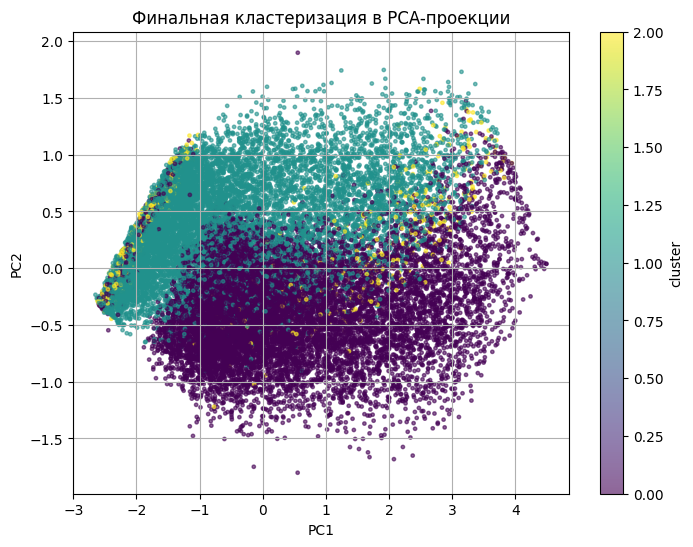

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    s=6,
    alpha=0.6,
)
plt.colorbar(label='cluster')
plt.title('Финальная кластеризация в PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

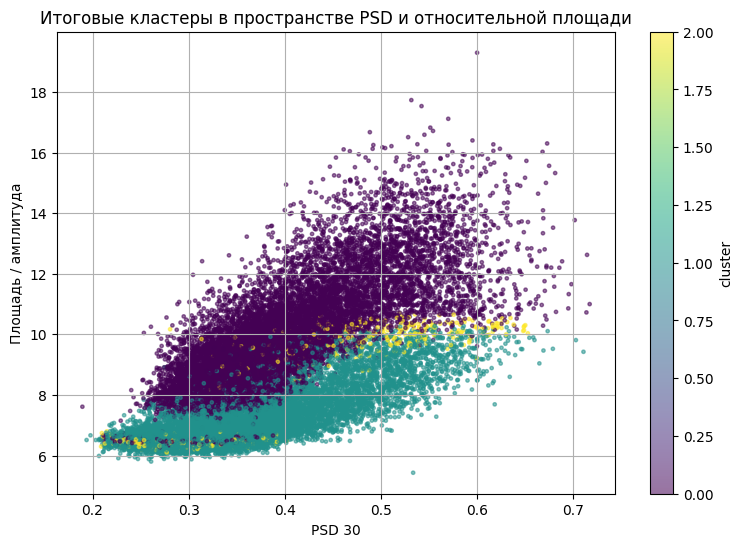

In [27]:
plt.figure(figsize=(9, 6))
plt.scatter(
    features['psd_30'],
    features['area_to_amplitude'],
    c=final_labels,
    s=6,
    alpha=0.55,
)
plt.colorbar(label='cluster')
plt.title('Итоговые кластеры в пространстве PSD и относительной площади')
plt.xlabel('PSD 30')
plt.ylabel('Площадь / амплитуда')
plt.grid(True)
plt.show()

In [28]:
standardized_features = pd.DataFrame(
    StandardScaler().fit_transform(features[model_features]),
    columns=model_features,
)
standardized_features['cluster'] = final_labels

cluster_means = standardized_features.groupby('cluster')[model_features].mean()
feature_importance = cluster_means.std(axis=0).sort_values(ascending=False)

feature_importance.head(15).rename('importance').to_frame()

,importance
area_to_amplitude,0.687282
tail_after_20_ratio,0.589014
decay_q90_q50,0.249664
std_time,0.242499
psd_30,0.183713
psd_60,0.045019


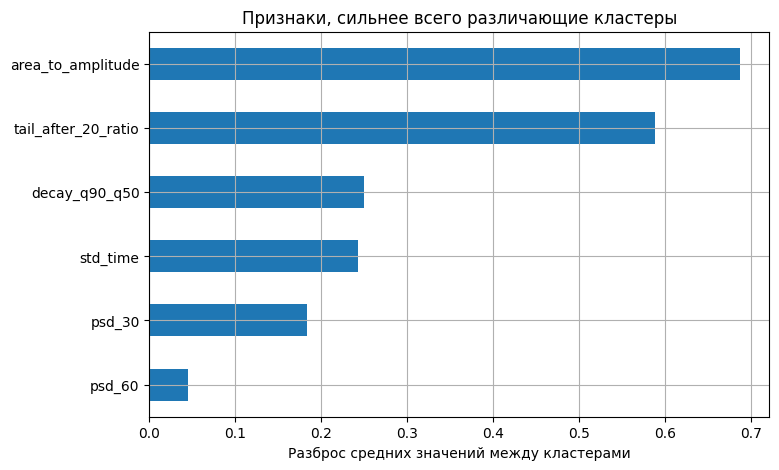

In [29]:
plt.figure(figsize=(8, 5))
feature_importance.head(15).sort_values().plot(kind='barh')
plt.title('Признаки, сильнее всего различающие кластеры')
plt.xlabel('Разброс средних значений между кластерами')
plt.grid(True)
plt.show()

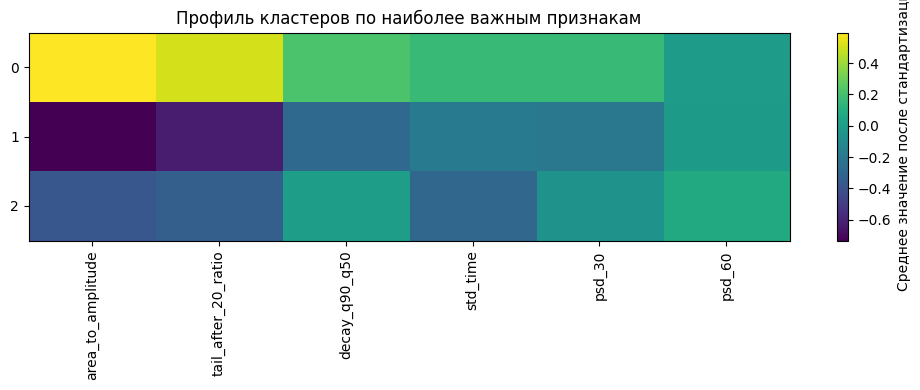

In [30]:
profile_columns = feature_importance.head(10).index
profile_for_heatmap = cluster_means[profile_columns]

plt.figure(figsize=(10, 4))
plt.imshow(profile_for_heatmap, aspect='auto')
plt.colorbar(label='Среднее значение после стандартизации')
plt.xticks(range(len(profile_columns)), profile_columns, rotation=90)
plt.yticks(range(len(profile_for_heatmap.index)), profile_for_heatmap.index)
plt.title('Профиль кластеров по наиболее важным признакам')
plt.tight_layout()
plt.show()

**Вывод по этапу интерпретации результатов.**  
Наиболее важными оказываются признаки, связанные с PSD, хвостом импульса и временной шириной. Это согласуется с физической постановкой: гамма-кванты и нейтроны могут давать импульсы с разной долей медленной компоненты, а неоднозначные сигналы находятся в зоне пересечения или имеют нетипичную форму.

## 9. Предсказание и подготовка submission

На этом этапе финальные метки кластеров записываются в файл `submission.csv` в формате соревнования: `index` и `cluster`. Порядок строк сохраняется таким же, как в исходных данных.

In [31]:
submission = pd.DataFrame({
    'index': np.arange(len(final_labels)),
    'cluster': final_labels.astype(int),
})

submission.to_csv('submission.csv', index=False)
submission.head()


,index,cluster
0,0,2
1,1,1
2,2,1
3,3,0
4,4,1


In [32]:
submission['cluster'].value_counts().sort_index()

cluster
0    12748
1     9956
2      775
Name: count, dtype: int64

**Вывод по этапу предсказания.**  
Финальный файл `submission.csv` сформирован для всех объектов датасета. Метки принимают значения 0, 1 и 2: два основных кластера соответствуют двум типам сигналов, а кластер 2 выделяет неоднозначные или аномальные импульсы.

## 10. Результат на Kaggle

Ниже приведён скриншот отправки решения на Kaggle.

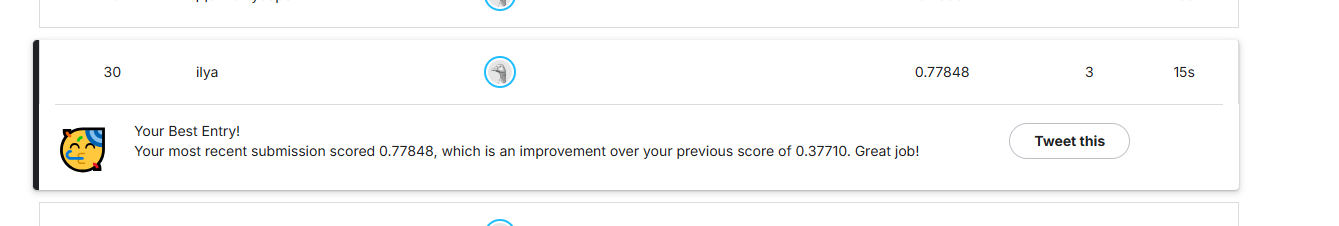

## 11. Общие выводы

В работе выполнена полная цепочка решения задачи кластеризации сигналов сцинтилляционного детектора:

- проведён EDA исходных сигналов, служебных признаков и базовых характеристик импульсов;
- выполнена предобработка: инверсия сигнала, коррекция базовой линии и переход к положительному импульсу;
- построены физически интерпретируемые признаки: амплитуда, площадь, PSD, доля хвоста, временная ширина и параметры спада;
- сравнены несколько алгоритмов кластеризации и наборов гиперпараметров;
- выбрана финальная PCA-схема, которая отделяет две основные ветви сигналов и выделяет неоднозначные наблюдения в отдельный кластер;
- проведена интерпретация кластеров через профили признаков и PCA-визуализацию;
- **Кластер 0** — сигналы с более выраженной хвостовой компонентой и большим отношением площади к амплитуде. Такие импульсы имеют более протяжённую форму и могут соответствовать одному из основных физических типов частиц, например нейтроноподобным сигналам.
- **Кластер 1** — сигналы с меньшей хвостовой компонентой и более компактной формой импульса. Такие сигналы быстрее спадают и могут соответствовать другому основному типу частиц, например гамма-подобным сигналам.
- **Кластер 2** — неоднозначные сигналы, расположенные около границы между двумя основными группами. В этот кластер попадают объекты с низкой уверенностью модели, а также потенциальные выбросы, смешанные импульсы или сигналы с нестандартной формой.

Финальное решение воспроизводимо: все случайные операции используют `RANDOM_STATE`, а порядок строк при формировании ответа не меняется.